C:\Users\Romain\AppData\Local\Temp\ipykernel_12052\3683616292.py:151: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range('2024-01-01', periods=1000, freq='1H')


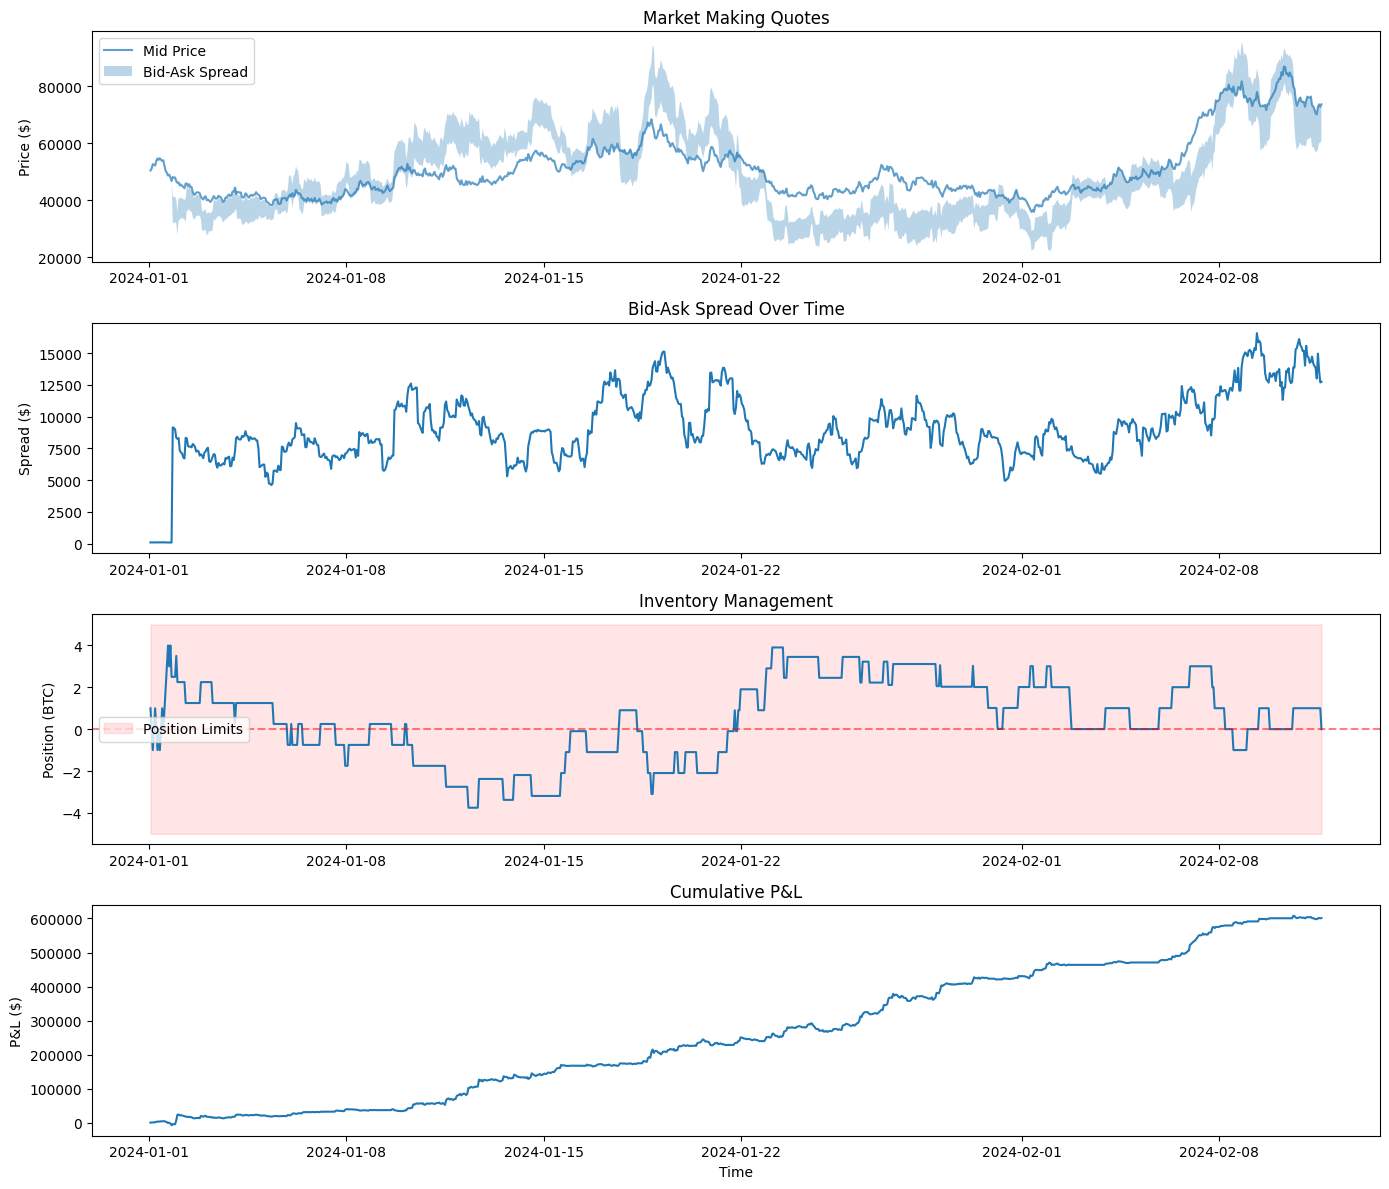


=== Performance Metrics ===
Final P&L: $601,372.36
Sharpe Ratio: -1.91
Max Inventory: 4.00 BTC
Avg Spread: $8999.92
Avg Inventory: 0.47 BTC


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple

@dataclass
class MMParameters:
    """Market making strategy parameters"""
    risk_aversion: float = 0.1  # Risk aversion parameter (gamma)
    volatility: float = 0.02    # Daily volatility estimate
    position_limit: int = 10    # Max inventory (in BTC)
    tick_size: float = 1.0      # Minimum price increment
    maker_fee: float = -0.0002  # Maker rebate (negative = you get paid)
    taker_fee: float = 0.0004   # Taker fee

class SimpleMarketMaker:
    """
    Simplified Avellaneda-Stoikov market making model
    """
    def __init__(self, params: MMParameters):
        self.params = params
        self.inventory = 0
        self.cash = 0
        self.pnl_history = []
        self.inventory_history = []

    def compute_quotes(self, mid_price: float, volatility: float) -> Tuple[float, float]:
        """
        Compute bid/ask quotes based on current inventory and market conditions

        Args:
            mid_price: Current mid price
            volatility: Current volatility estimate

        Returns:
            (bid_price, ask_price)
        """
        # Base spread proportional to volatility and risk aversion
        base_spread = volatility * self.params.risk_aversion * mid_price

        # Inventory adjustment (skew quotes to reduce inventory)
        inventory_skew = self.inventory * volatility * self.params.risk_aversion * mid_price * 0.5

        # Compute quotes
        bid_offset = base_spread / 2 + inventory_skew
        ask_offset = base_spread / 2 - inventory_skew

        bid_price = mid_price - bid_offset
        ask_price = mid_price + ask_offset

        # Round to tick size
        bid_price = np.round(bid_price / self.params.tick_size) * self.params.tick_size
        ask_price = np.round(ask_price / self.params.tick_size) * self.params.tick_size

        return bid_price, ask_price

    def process_trade(self, side: str, price: float, size: float = 1.0):
        """Process a trade execution"""
        if side == 'buy':
            self.inventory += size
            self.cash -= price * size * (1 + self.params.maker_fee)
        else:  # sell
            self.inventory -= size
            self.cash += price * size * (1 - self.params.maker_fee)

    def get_pnl(self, current_price: float) -> float:
        """Calculate current P&L"""
        return self.cash + self.inventory * current_price

# Simulation
def simulate_market_making(prices: pd.Series, params: MMParameters):
    """
    Backtest simple market making strategy

    Args:
        prices: Time series of mid prices
        params: MM parameters
    """
    mm = SimpleMarketMaker(params)

    # Calculate rolling volatility
    returns = prices.pct_change()
    volatility = returns.rolling(window=20).std() * np.sqrt(365 * 24)  # Annualized hourly vol
    volatility = volatility.fillna(params.volatility)

    results = []

    for i in range(len(prices)):
        if i == 0:
            continue

        current_price = prices.iloc[i]
        current_vol = volatility.iloc[i]

        # Compute quotes
        bid, ask = mm.compute_quotes(current_price, current_vol)

        # Simulate order fills (simplified)
        # In reality, you'd use actual order book data and fill probability models
        price_change = prices.iloc[i] - prices.iloc[i-1]

        # Simple fill logic:
        # - If price moves up, assume we sold at ask
        # - If price moves down, assume we bought at bid
        # - Probability of fill increases with price movement

        fill_probability = min(abs(price_change) / (ask - bid), 1.0)

        if price_change > 0 and np.random.random() < fill_probability:
            # Price went up, we likely sold at ask
            if mm.inventory > -params.position_limit:
                mm.process_trade('sell', ask)

        elif price_change < 0 and np.random.random() < fill_probability:
            # Price went down, we likely bought at bid
            if mm.inventory < params.position_limit:
                mm.process_trade('buy', bid)

        # Check if we need to flatten inventory (hit the market)
        if abs(mm.inventory) > params.position_limit * 0.8:
            # Aggressive inventory reduction (pay taker fee)
            flatten_size = mm.inventory * 0.5
            if flatten_size > 0:
                mm.cash += current_price * flatten_size * (1 - params.taker_fee)
            else:
                mm.cash += current_price * flatten_size * (1 + params.taker_fee)
            mm.inventory -= flatten_size

        # Record state
        pnl = mm.get_pnl(current_price)
        results.append({
            'timestamp': prices.index[i],
            'price': current_price,
            'bid': bid,
            'ask': ask,
            'spread': ask - bid,
            'inventory': mm.inventory,
            'pnl': pnl,
            'volatility': current_vol
        })

        mm.pnl_history.append(pnl)
        mm.inventory_history.append(mm.inventory)

    return pd.DataFrame(results)

# Example usage with BTC data
# You would load real crypto data here
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=1000, freq='1H')
# Simulate GBM for BTC price
returns = np.random.normal(0, 0.02, len(dates))
prices = pd.Series(50000 * np.exp(np.cumsum(returns)), index=dates)

params = MMParameters(
    risk_aversion=0.1,
    volatility=0.02,
    position_limit=5,
    tick_size=1.0
)

results = simulate_market_making(prices, params)

# Analysis
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Price and quotes
axes[0].plot(results['timestamp'], results['price'], label='Mid Price', alpha=0.7)
axes[0].fill_between(results['timestamp'], results['bid'], results['ask'],
                      alpha=0.3, label='Bid-Ask Spread')
axes[0].set_title('Market Making Quotes')
axes[0].legend()
axes[0].set_ylabel('Price ($)')

# Spread
axes[1].plot(results['timestamp'], results['spread'])
axes[1].set_title('Bid-Ask Spread Over Time')
axes[1].set_ylabel('Spread ($)')

# Inventory
axes[2].plot(results['timestamp'], results['inventory'])
axes[2].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[2].fill_between(results['timestamp'], -params.position_limit, params.position_limit,
                      alpha=0.1, color='red', label='Position Limits')
axes[2].set_title('Inventory Management')
axes[2].set_ylabel('Position (BTC)')
axes[2].legend()

# P&L
axes[3].plot(results['timestamp'], results['pnl'])
axes[3].set_title('Cumulative P&L')
axes[3].set_ylabel('P&L ($)')
axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()

# Performance metrics
final_pnl = results['pnl'].iloc[-1]
pnl_returns = results['pnl'].pct_change().dropna()
sharpe = pnl_returns.mean() / pnl_returns.std() * np.sqrt(365 * 24) if pnl_returns.std() > 0 else 0
max_inventory = results['inventory'].abs().max()

print(f"\n=== Performance Metrics ===")
print(f"Final P&L: ${final_pnl:,.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Inventory: {max_inventory:.2f} BTC")
print(f"Avg Spread: ${results['spread'].mean():.2f}")
print(f"Avg Inventory: {results['inventory'].mean():.2f} BTC")